# Ice Shelf Calving: Quantum Graph Theoretic Pipeline

**Project:** Craiceann-Ice  
**Goal:** Predict fracture propagation by solving Weighted Max-Cut on a Quantum Computer
**Goal:** Run the resulting 

### Team Structure Integration
* **Part 1 :** Physics Engine. Calculates Energy Release Rates ($G$) from fracture mechanics.
* **Part 2 :** Normalization & Hamiltonian Encoding.
* **Part 3 :** Quantum Solver (QAOA).

In [3]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Qiskit Imports
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeTorino

print("Pipeline Environment Ready.")

from qiskit_ibm_runtime import QiskitRuntimeService


# Initialize the service (update credentials if not saved)
# service = QiskitRuntimeService(token="<cloud_api_key>", instance="<instance_CRN>")
service = QiskitRuntimeService()  # Use if credentials are already saved

# Find all backends that support dynamic circuits
dc_backends = service.backends(dynamic_circuits=True)
print("Backends supporting dynamic circuits:")
for backend in dc_backends:
    print(f"- {backend.name}")


Pipeline Environment Ready.
Backends supporting dynamic circuits:
- ibm_marrakesh
- ibm_kingston
- ibm_fez


## Part 1: Jacks Physics and Graphs
**Responsibility:** Define the graph topology and calculate physical edge weights ($J/m^2$).
 
* **Input:** Material properties (Ice), Stress Intensity Factors ($K_I, K_{II}$).
* **Output:** `networkx` Graph where `weight` = Energy Release Rate.

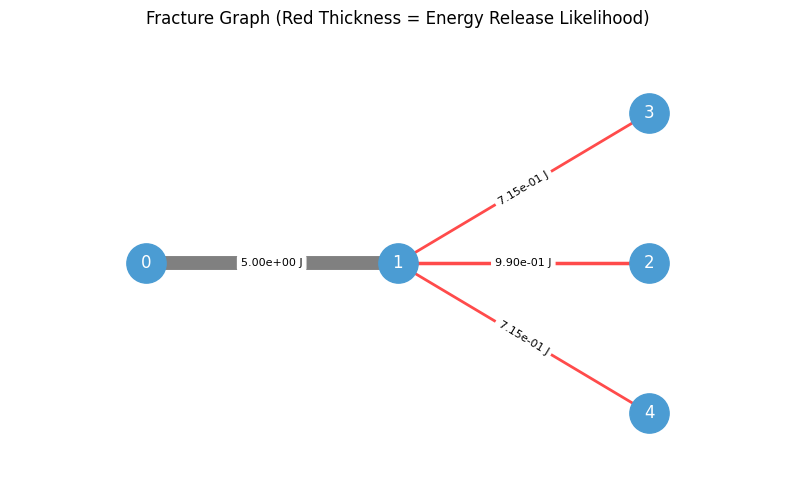

In [4]:
def calculate_energy_release(K_I, K_II, E=9e9, nu=0.33):
    """
    Calculates G (Energy Release Rate) based on Irwin's relation.
    """
    E_eff = E / (1.0 - nu**2) # Plane strain
    return (K_I**2 + K_II**2) / E_eff

def get_physics_graph(use_branching_angles=True):
    """
    Generates the fracture graph.
    Set use_branching_angles=True to see the 'Fan' structure.
    """
    G = nx.Graph()
    
    # Common Physics Parameters
    sigma_inf = 1e5
    
    if not use_branching_angles:
        # --- LINEAR CRACK (Jack's Original Base) ---
        nodes = {0: (0,0), 1: (1,0), 2: (2,0)}
        segments = [(0, 1, 0.5), (1, 2, 1.0)] 
        
        for u, v, a in segments:
            K_I = sigma_inf * np.sqrt(np.pi * a)
            w = calculate_energy_release(K_I, 0)
            G.add_edge(u, v, weight=w, type='existing')
            
    else:
        # --- BRANCHING CRACK (The "Fan" Strategy) ---
        nodes = {0: (0,0), 1: (1,0), 2: (2,0), 3: (2, 0.5), 4: (2, -0.5)}
        
        # 1. History Edge (Already broken, essentially infinite risk)
        # We give it a high weight so it's visually distinct, but treated as 'done'
        G.add_edge(0, 1, weight=5.0, type='history')
        
        # 2. Candidate Paths (Fan from Tip 1)
        K_I_base = 1e5
        
        # Option A: Straight (0 deg) - Highest Energy Release
        w_0 = calculate_energy_release(K_I_base, 0)
        G.add_edge(1, 2, weight=w_0, type='candidate')
        
        # Option B & C: Kinked (+/- 45 deg) - Lower Energy Release due to mixed mode
        # Simulated reduction factor for being off-axis
        w_kink = calculate_energy_release(K_I_base * 0.85, 0) 
        G.add_edge(1, 3, weight=w_kink, type='candidate')
        G.add_edge(1, 4, weight=w_kink, type='candidate')

    # Attach positions for visualization
    nx.set_node_attributes(G, nodes, 'pos')
    return G

# Generate the graph
G_fracture = get_physics_graph(use_branching_angles=True)

# --- CORRECTED VISUALIZATION ---
def visualize_graph(G):
    pos = nx.get_node_attributes(G, 'pos')
    
    # Extract weights for scaling
    weights = np.array([G[u][v]['weight'] for u,v in G.edges()])
    
    # Scale widths dynamically for display (Between 2 and 10 pixels)
    # This prevents the "All Black Screen" issue
    min_w, max_w = weights.min(), weights.max()
    if max_w > min_w:
        widths = 2 + 8 * (weights - min_w) / (max_w - min_w)
    else:
        widths = [5] * len(weights)
    
    # Color coding
    edge_colors = ['grey' if G[u][v].get('type') == 'history' else '#FF4B4B' for u,v in G.edges()]
    
    plt.figure(figsize=(10, 6))
    
    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, node_color='#4B9CD3', node_size=800)
    
    # Draw Edges with corrected widths
    nx.draw_networkx_edges(G, pos, width=widths, edge_color=edge_colors)
    
    # Draw Labels
    nx.draw_networkx_labels(G, pos, font_color='white')
    
    # Draw Weight Labels (Scientific Notation)
    edge_labels = {e: f"{G.edges[e]['weight']:.2e} J" for e in G.edges}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    
    plt.title("Fracture Graph (Red Thickness = Energy Release Likelihood)")
    plt.margins(0.2) # Give it room to breathe
    plt.axis('off')
    plt.show()

visualize_graph(G_fracture)

## Part 2: The Bridge (Integration)
**Responsibility:** Translate Physics $\to$ Math.

1.  **Normalization (Crucial):** Maps $10^{-10}$ J energy scales to $[0.1, 1.0]$ for the optimizer.
2.  **Hamiltonian:** Converts graph edges to Ising operators ($Z_i Z_j$).

### Why Normalize?
Our physical Energy Release Rates ($G$) are massive numbers (e.g., $10^5$ J/m²). However, in the Quantum Circuit (QAOA), these weights translate directly into **Rotation Angles** ($\theta$) for the qubits.

Quantum rotations are periodic ($0 \equiv 2\pi \equiv 4\pi$).
* **The Problem:** If we feed a weight of $100,000$ into the circuit, the qubit rotates $100,000$ radians.
    $$100,000 \pmod{2\pi} \approx 4.85 \text{ rad}$$
    This "wrapping around" destroys the relative order of our data. A huge energy release might accidentally wrap around to a small angle, while a small energy release wraps to a large one.

In [5]:
def to_ising_hamiltonian(G_nx):
    edges = []
    weights = []
    for u, v, data in G_nx.edges(data=True):
        edges.append((u, v))
        weights.append(data['weight'])
    
    weights = np.array(weights)
    
    # --- NORMALIZATION FIX (From David's Notebook) ---
    # Without this, COBYLA/SPSA optimizers fail on physical scales.
    if np.max(weights) > np.min(weights):
        w_norm = 0.1 + 0.9 * (weights - np.min(weights)) / (np.max(weights) - np.min(weights))
    else:
        w_norm = np.ones_like(weights)
        
    print(f"Original Weights: {weights}")
    print(f"Normalized Weights: {w_norm}")

    # Build Pauli Operator
    pauli_list = []
    num_qubits = G_nx.number_of_nodes()
    
    for (u, v), w in zip(edges, w_norm):
        # Create string like "IIZZ"
        op_list = ['I'] * num_qubits 
        # Note: Qiskit is Little-Endian (index 0 is rightmost)
        op_list[num_qubits - 1 - u] = 'Z'
        op_list[num_qubits - 1 - v] = 'Z'
        
        # MaxCut Hamiltonian term: w * Z_i * Z_j
        pauli_list.append(("".join(op_list), w))
        
    return SparsePauliOp.from_list(pauli_list)

H_c = to_ising_hamiltonian(G_fracture)
print(f"\nConstructed Hamiltonian:\n{H_c}")

Original Weights: [5.         0.99011111 0.71535528 0.71535528]
Normalized Weights: [1.         0.15771313 0.1        0.1       ]

Constructed Hamiltonian:
SparsePauliOp(['IIIZZ', 'IIZZI', 'IZIZI', 'ZIIZI'],
              coeffs=[1.        +0.j, 0.15771313+0.j, 0.1       +0.j, 0.1       +0.j])



 ## Part 3: QAOA
 **Responsibility:** Construct and Transpile the QAOA circuit.

 * **Ansatz:** QAOA (Depth $p=1$).
 * **Backend:** Use the least busy

In [6]:
def setup_qaoa(hamiltonian):
    # 1. Define the Variational Form
    ansatz = QAOAAnsatz(cost_operator=hamiltonian, reps=1)
    ansatz.measure_all()
    
    # 2. Transpile for Hardware

    # Choose the least busy available backend to minimize queue time with real hardware only
    backend = service.least_busy(operational=True, simulator=False)
    print(f"Using backend: {backend.name}")
    print(f"Backend properties: {backend.num_qubits} qubits")
    
    
    print(f"Targeting Backend: {backend.name} ({backend.num_qubits} qubits)")
    
    pm = generate_preset_pass_manager(target=backend.target, optimization_level=3)
    isa_circuit = pm.run(ansatz)
    
    return isa_circuit

# Run Setup
qc = setup_qaoa(H_c)

print("\n--- Compilation Successful ---")
print(f"Physical Qubits Used: {qc.num_qubits}")
print(f"Circuit Depth: {qc.depth()}")
print(f"Op Count: {qc.count_ops()}")

Using backend: ibm_marrakesh
Backend properties: 156 qubits
Targeting Backend: ibm_marrakesh (156 qubits)

--- Compilation Successful ---
Physical Qubits Used: 156
Circuit Depth: 43
Op Count: OrderedDict({'rz': 30, 'sx': 23, 'cz': 11, 'measure': 5, 'barrier': 1})


### Visualization of the Quantum Circuit
This is the actual instruction set sent to the QPU.

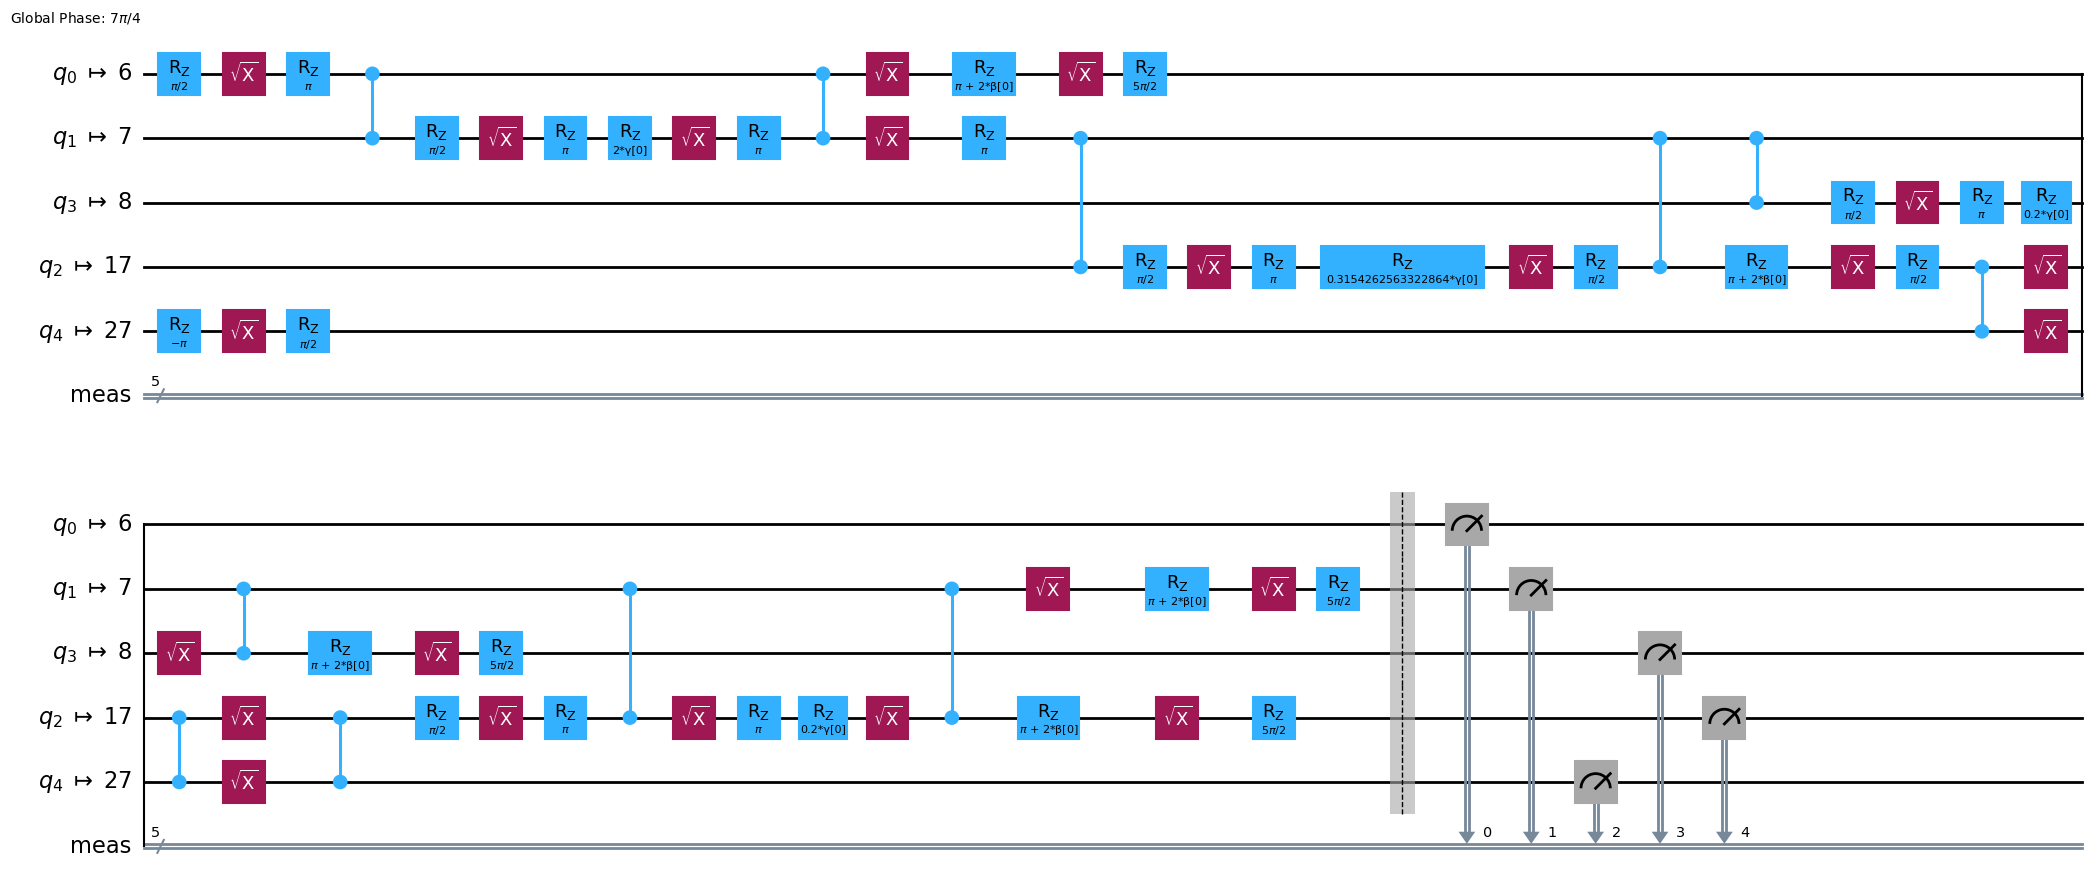

In [7]:
qc.draw('mpl', fold=30, idle_wires=False)

In [8]:
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)


transpiled_circuit = pm.run(qc)

In [12]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)

# The 'shots' parameter determines how many times to execute the circuit
shots = 1024
param_values = np.random.rand(qc.num_parameters)
# Submit the sampling job with the transpiled circuit
job = sampler.run([(transpiled_circuit,param_values)])

print(f"Sampler Job ID: {job.job_id()}")
print(f"Requested shots: {shots}")

Sampler Job ID: d8ecl7o7jphs739khq10
Requested shots: 1024


In [13]:
result=job.result()

In [17]:

jobby = []
results = []
for i in range(100): 
    param_values = np.random.rand(qc.num_parameters)
    jobby.append (sampler.run ([(transpiled_circuit,param_values)]))
    print(f"Sampler Job ID: {jobby[i].job_id()}")
    results.append(jobby[i].result())
    

Sampler Job ID: d8ecrabalsvc73903nh0
Sampler Job ID: d8ecrcbo3njc73euim10
Sampler Job ID: d8ecrebo3njc73euim4g
Sampler Job ID: d8ecrgbo3njc73euim6g
Sampler Job ID: d8ecri07jphs739ki0r0
Sampler Job ID: d8ecrk87jphs739ki0ug
Sampler Job ID: d8ecrpro3njc73euimhg
Sampler Job ID: d8ecrt87jphs739ki18g
Sampler Job ID: d8ecrvbo3njc73euimp0
Sampler Job ID: d8ecs19vjngc73ao74fg
Sampler Job ID: d8ecs3bo3njc73euimug
Sampler Job ID: d8ecs5bo3njc73euin4g
Sampler Job ID: d8ecs7balsvc73903ok0
Sampler Job ID: d8ecs9bo3njc73euinc0
Sampler Job ID: d8ecscbo3njc73euinhg
Sampler Job ID: d8ecse3alsvc73903otg
Sampler Job ID: d8ecsg3alsvc73903p20
Sampler Job ID: d8ecsi3alsvc73903p5g
Sampler Job ID: d8ecsk1vjngc73ao758g
Sampler Job ID: d8ecslpvjngc73ao75cg
Sampler Job ID: d8ecsnro3njc73euio20
Sampler Job ID: d8ecst9vjngc73ao75s0
Sampler Job ID: d8ect107jphs739ki340
Sampler Job ID: d8ect2o7jphs739ki390
Sampler Job ID: d8ect4ralsvc73903q70
Sampler Job ID: d8ect707jphs739ki3g0
Sampler Job ID: d8ect8o7jphs739ki3k0
S

/Users/cfillekes/What-About-Bob/TheCraic/craic_env/lib/python3.14/site-packages/qiskit_ibm_runtime/qiskit_runtime_service.py:1224: UserWarning: This instance has met its usage limit. Workloads will not run until time ismade available. Check https://quantum.cloud.ibm.com/instances/crn%3Av1%3Abluemix%3Apublic%3Aquantum-computing%3Aus-east%3Aa%2Fad18854b8f554dc2bf197429b5c46b91%3Afd503bf8-41e4-416a-8f6a-2727ebc71fc3%3A%3A for more details.
  warnings.warn(


Sampler Job ID: d8ectppvjngc73ao77ig
Sampler Job ID: d8ectvbo3njc73euiq10


RuntimeInvalidStateError: 'Unable to retrieve result for job d8ectvbo3njc73euiq10. Job was cancelled.'